In [1]:
import polars as pl

### Resumen del capítulo: Visualización de datos

En este capítulo aprenderás a:

- Crear rápidamente gráficos de barras, dispersión, densidad e histogramas usando Polars y Altair.
- Componer y superponer múltiples gráficos.
- Crear visualizaciones interactivas.
- Visualizar millones de puntos en mapas.
- Utilizar paquetes alternativos de visualización como hvPlot y plotnine.
- Crear tablas visualmente atractivas con Great Tables.

Al finalizar, sabrás qué ofrecen Altair, hvPlot, plotnine y Great Tables, cuándo usar cada uno y cómo integrarlos con Polars para análisis y visualización de datos.

## NYC Bike Trips

In [2]:
trips = pl.read_parquet("data/citibike/*.parquet")
print(trips[:, :4])
print(trips[:, 4:7])
print(trips[:, 7:11])
print(trips[:, 11:])

shape: (2_638_971, 4)
┌───────────┬────────────┬─────────────────────────┬─────────────────────────┐
│ bike_type ┆ rider_type ┆ datetime_start          ┆ datetime_end            │
│ ---       ┆ ---        ┆ ---                     ┆ ---                     │
│ cat       ┆ cat        ┆ datetime[μs]            ┆ datetime[μs]            │
╞═══════════╪════════════╪═════════════════════════╪═════════════════════════╡
│ electric  ┆ member     ┆ 2024-03-01 00:00:02.490 ┆ 2024-03-01 00:27:39.295 │
│ electric  ┆ member     ┆ 2024-03-01 00:00:04.120 ┆ 2024-03-01 00:09:29.384 │
│ electric  ┆ casual     ┆ 2024-03-01 00:00:05.209 ┆ 2024-03-01 00:03:34.692 │
│ classic   ┆ member     ┆ 2024-03-01 00:00:05.259 ┆ 2024-03-01 00:31:02.219 │
│ electric  ┆ member     ┆ 2024-03-01 00:00:09.837 ┆ 2024-03-01 00:11:42.320 │
│ …         ┆ …          ┆ …                       ┆ …                       │
│ classic   ┆ member     ┆ 2024-03-31 23:55:29.002 ┆ 2024-03-31 23:57:10.376 │
│ classic   ┆ member     ┆ 202

In [3]:
import altair as alt

| Namespace         | Método                | Descripción                                                                                   |
|-------------------|-----------------------|----------------------------------------------------------------------------------------------|
| `df.plot`         | `bar()`               | Dibuja un gráfico de barras, puede ser apilado o agrupado.                                   |
| `df.plot`         | `line()`              | Dibuja un gráfico de líneas, útil para series temporales.                                    |
| `df.plot`         | `point()`             | Dibuja un diagrama de dispersión (scatter) para comparar dos variables.                      |
| `df.plot`         | `scatter()`           | Alias de `point()`, también crea un diagrama de dispersión.                                  |
| `series.plot`     | `hist()`              | Dibuja la distribución de una o más variables como histogramas (conjunto de bins).           |
| `series.plot`     | `density()`           | Dibuja la estimación de densidad kernel (KDE) de una o más variables.                        |
| `series.plot`     | `line()`              | Dibuja un gráfico de líneas para una serie temporal o secuencia de datos.                    |

## Plotting DataFrames

In [4]:
trips_speed  = trips.select(
    pl.col('distance'),
    pl.col('duration').dt.total_seconds() / 3600.0,
    pl.col('bike_type'),
).with_columns(
    (pl.col('distance') / pl.col('duration')).alias('speed')
)

trips_speed

distance,duration,bike_type,speed
f64,f64,cat,f64
4.842569,0.46,"""electric""",10.527324
2.659582,0.156944,"""electric""",16.94601
0.398795,0.058056,"""electric""",6.869194
5.09153,0.515556,"""classic""",9.875812
3.08728,0.192222,"""electric""",16.060992
…,…,…,…
0.272175,0.028056,"""classic""",9.701291
0.492269,0.058333,"""classic""",8.438897
0.406138,0.029444,"""classic""",13.793378


In [5]:
trips_speed.describe()

statistic,distance,duration,bike_type,speed
str,f64,f64,str,f64
"""count""",2.638971e6,2.638971e6,"""2638971""",2.638971e6
"""null_count""",0.0,0.0,"""0""",0.0
"""mean""",1.95055,0.206076,null,11.149556
"""std""",1.698171,0.328918,null,5.780136
"""min""",0.0,0.016667,null,0.0
"""25%""",0.828994,0.083611,null,8.427098
"""50%""",1.445999,0.142778,null,11.055646
"""75%""",2.512934,0.247778,null,13.87119
"""max""",29.906818,25.616667,null,890.214126


In [6]:
trips_speed.plot.scatter(
    x="distance",
    y="duration",
    color="bike_type",
)

MaxRowsError: The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.Chart(...)

In [7]:
trips_speed = (
    trips.filter(pl.col("station_start") == "W 70 St & Amsterdam Ave")
    .select(
        pl.col("distance"),
        pl.col("duration").dt.total_seconds() / 3600,
        pl.col("bike_type"),
    )
    .with_columns(speed=pl.col("distance") / pl.col("duration"))
)
trips_speed

distance,duration,bike_type,speed
f64,f64,cat,f64
0.596344,0.039167,"""electric""",15.225797
1.134568,0.153611,"""classic""",7.385977
4.586869,0.492778,"""electric""",9.30819
0.839622,0.046111,"""electric""",18.208666
0.351954,0.027778,"""electric""",12.670335
…,…,…,…
2.850176,0.172778,"""electric""",16.496196
0.590008,0.060833,"""classic""",9.698761
1.821509,0.133611,"""electric""",13.632919


In [8]:
trips_speed.plot.scatter(
    x="distance",
    y="duration",
    color="bike_type:N",  
)

alt.Chart(...)

##  Too Large to Handle

In [9]:
import altair as alt
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [10]:
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [11]:
trips_type_counts = trips.group_by("rider_type", "bike_type").len()
trips_type_counts

rider_type,bike_type,len
cat,cat,u32
"""casual""","""electric""",294679
"""member""","""electric""",1412598
"""member""","""classic""",811168
"""casual""","""classic""",120526


In [12]:
trips_type_counts.plot.bar(
    x="rider_type", 
    y="len", 
    fill="bike_type:N", # 'by' creates the groups/colors
).properties(
    width=600,
)

alt.Chart(...)

## Plotting Series

In [13]:
trips_speed["duration"].plot.kde()

alt.Chart(...)

In [14]:
trips_speed["distance"].plot.hist()

alt.Chart(...)

In [15]:
trips_hour_num_speed = (
    trips.sort("datetime_start")
    .group_by_dynamic("datetime_start", every="1h")
    .agg(
        num_trips=pl.len(),
        speed=(
            pl.col("distance") / (pl.col("duration").dt.total_seconds() / 3600)
        ).mean(),
    ).filter(pl.col("datetime_start") > pl.date(2024, 3, 26))
)
trips_hour_num_speed

datetime_start,num_trips,speed
datetime[μs],u32,f64
2024-03-26 01:00:00,295,13.164779
2024-03-26 02:00:00,181,13.584443
2024-03-26 03:00:00,119,12.500417
2024-03-26 04:00:00,222,13.880642
2024-03-26 05:00:00,878,13.995939
…,…,…
2024-03-31 19:00:00,5170,10.588102
2024-03-31 20:00:00,3640,10.972232
2024-03-31 21:00:00,2813,11.660278


In [16]:
trips_hour_num_speed.plot.line(
    x="datetime_start",
    y="num_trips")

alt.Chart(...)

## Pandas-Like Plotting with hvPlot

In [17]:
import hvplot.polars

In [18]:
trips_speed.hvplot.scatter(
    x="distance",
    y="duration",
    color="bike_type",
    xlabel='distance (km)',
    ylabel='duration (hours)',
    ylim=(0, 2),
)

:Scatter   [distance]   (duration,bike_type)

## Pandas as backup for plotting

In [19]:
trips_per_day_hour = (
    trips.sort("datetime_start")
    .group_by_dynamic("datetime_start", every="1h")
    .agg(pl.len())
)
trips_per_day_hour

datetime_start,len
datetime[μs],u32
2024-03-01 00:00:00,787
2024-03-01 01:00:00,446
2024-03-01 02:00:00,301
2024-03-01 03:00:00,158
2024-03-01 04:00:00,208
…,…
2024-03-31 19:00:00,5170
2024-03-31 20:00:00,3640
2024-03-31 21:00:00,2813


In [20]:
import hvplot.pandas
trips_per_day_hour.to_pandas().hvplot.heatmap(
    x='datetime_start.hour', y='datetime_start.day', C='len', cmap='reds'
)

:HeatMap   [datetime_start.hour,datetime_start.day]   (len)

## Manual Transformations

In [21]:
trips_type_counts.hvplot.bar(
    x="rider_type", 
    y="len", 
    by="bike_type", 
    ylabel='count',
    stacked=True,
    color=["orange", "green"]
)

:Bars   [rider_type,bike_type]   (len)

## Changing Plotting Backends

In [22]:
import hvplot

hvplot.extension('bokeh')

## Plotting Points on a Map

In [24]:
trips.hvplot.points(
    x="lon_start",
    y="lat_start",
    datashade=True,
    geo=True,
    tiles="CartoLight",
    width=800,
    height=600,
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'9c925c50-2aa9-400c-a9a4-4af37ecdc37f': {'version…

## Composing Plots

In [28]:
(
    trips_hour_num_speed.hvplot.line(
        x="datetime_start",
        y="num_trips",
    )
    + trips_hour_num_speed.hvplot.line(
        x="datetime_start",
        y="speed",
    )
).cols(1)

:Layout
   .Curve.I  :Curve   [datetime_start]   (num_trips)
   .Curve.II :Curve   [datetime_start]   (speed)

In [29]:
(
    trips_hour_num_speed.hvplot.line(
        x="datetime_start",
        y="num_trips",
    )
    * trips_hour_num_speed.filter(
        pl.col("num_trips") > 9000
    ).hvplot.scatter(
        x="datetime_start",
        y="num_trips",
        c='red',
        s=50    
    )
)

:Overlay
   .Curve.I   :Curve   [datetime_start]   (num_trips)
   .Scatter.I :Scatter   [datetime_start]   (num_trips)

In [31]:
trips_per_hour = (
    trips.sort("datetime_start")
    .group_by_dynamic("datetime_start", group_by="borough_start", every="1h")
    .agg(pl.len())
    .with_columns(date=pl.col("datetime_start").dt.date())
)
trips_per_hour

borough_start,datetime_start,len,date
str,datetime[μs],u32,date
"""Bronx""",2024-03-01 00:00:00,43,2024-03-01
"""Bronx""",2024-03-01 01:00:00,14,2024-03-01
"""Bronx""",2024-03-01 02:00:00,17,2024-03-01
"""Bronx""",2024-03-01 03:00:00,6,2024-03-01
"""Bronx""",2024-03-01 04:00:00,10,2024-03-01
…,…,…,…
"""Manhattan""",2024-03-31 19:00:00,3113,2024-03-31
"""Manhattan""",2024-03-31 20:00:00,2184,2024-03-31
"""Manhattan""",2024-03-31 21:00:00,1668,2024-03-31


In [32]:
trips_per_hour.hvplot.line(
    x="datetime_start",
    by="borough_start",
    groupby="date",
    widget_location='left_top'
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'216d61b4-3a0c-48d0-bb97-452b54636612': {'version…

### Introducing Plotline

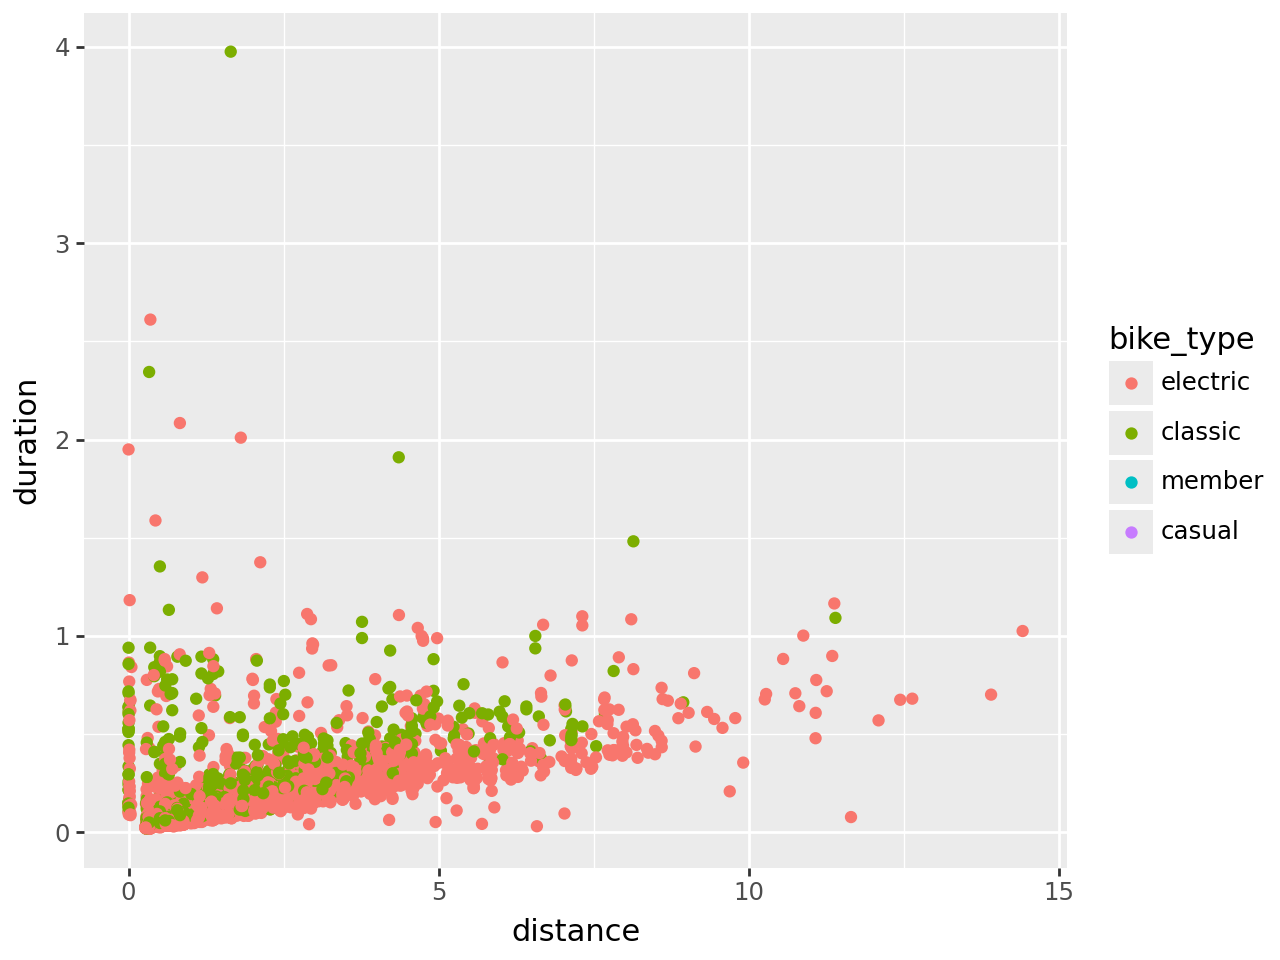

In [36]:
# Plot for exploration
from plotnine import *
(
    ggplot(trips_speed, aes(x='distance', y='duration', color='bike_type'))
    + geom_point()
)

c:\Users\evolu\anaconda3\envs\polars_env\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 72'. Pick better value with 'binwidth'.


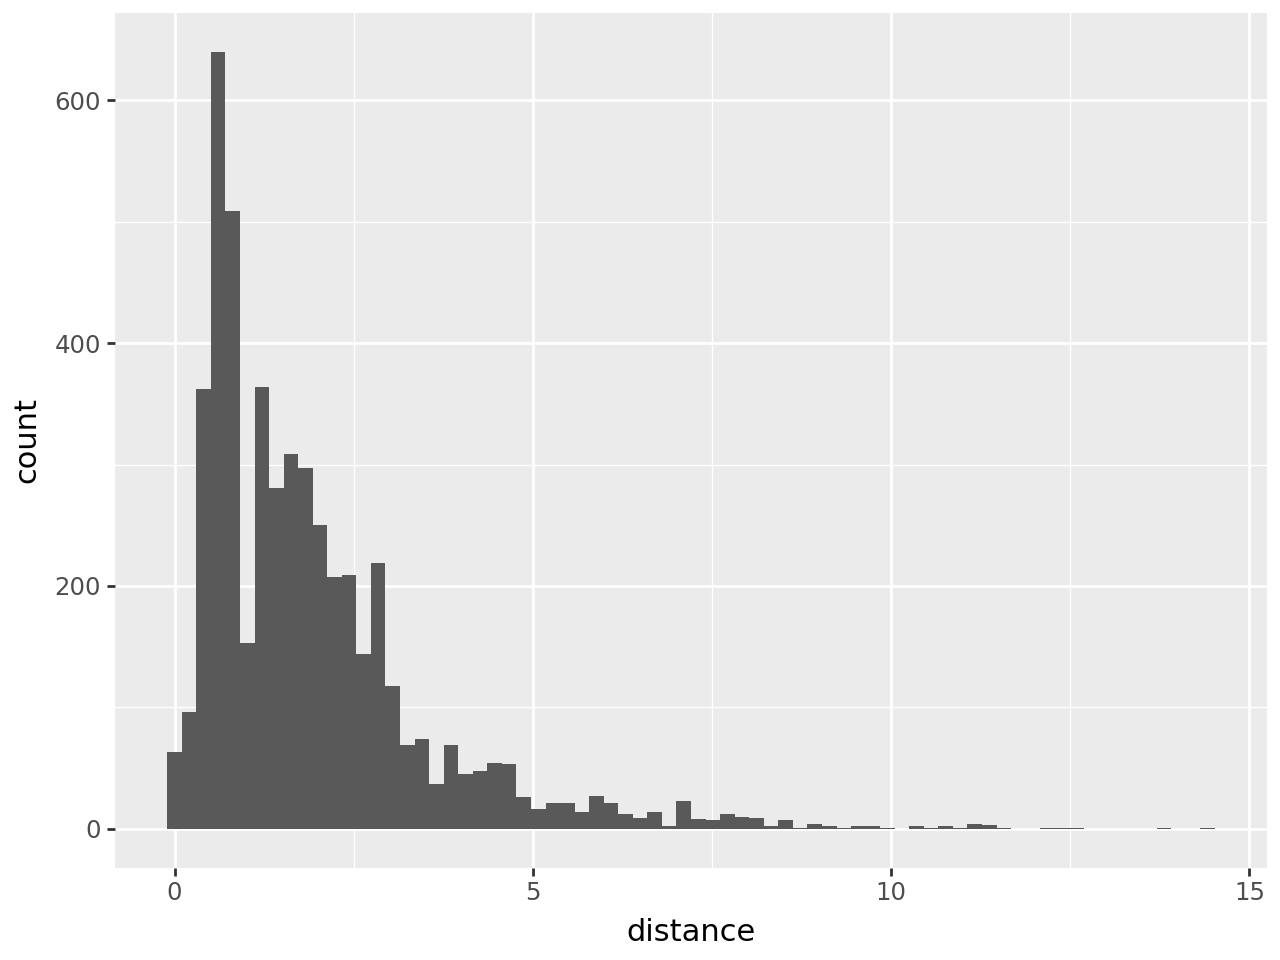

In [40]:
(
    ggplot(trips_speed, aes(x='distance')) 
    + geom_histogram() 
)

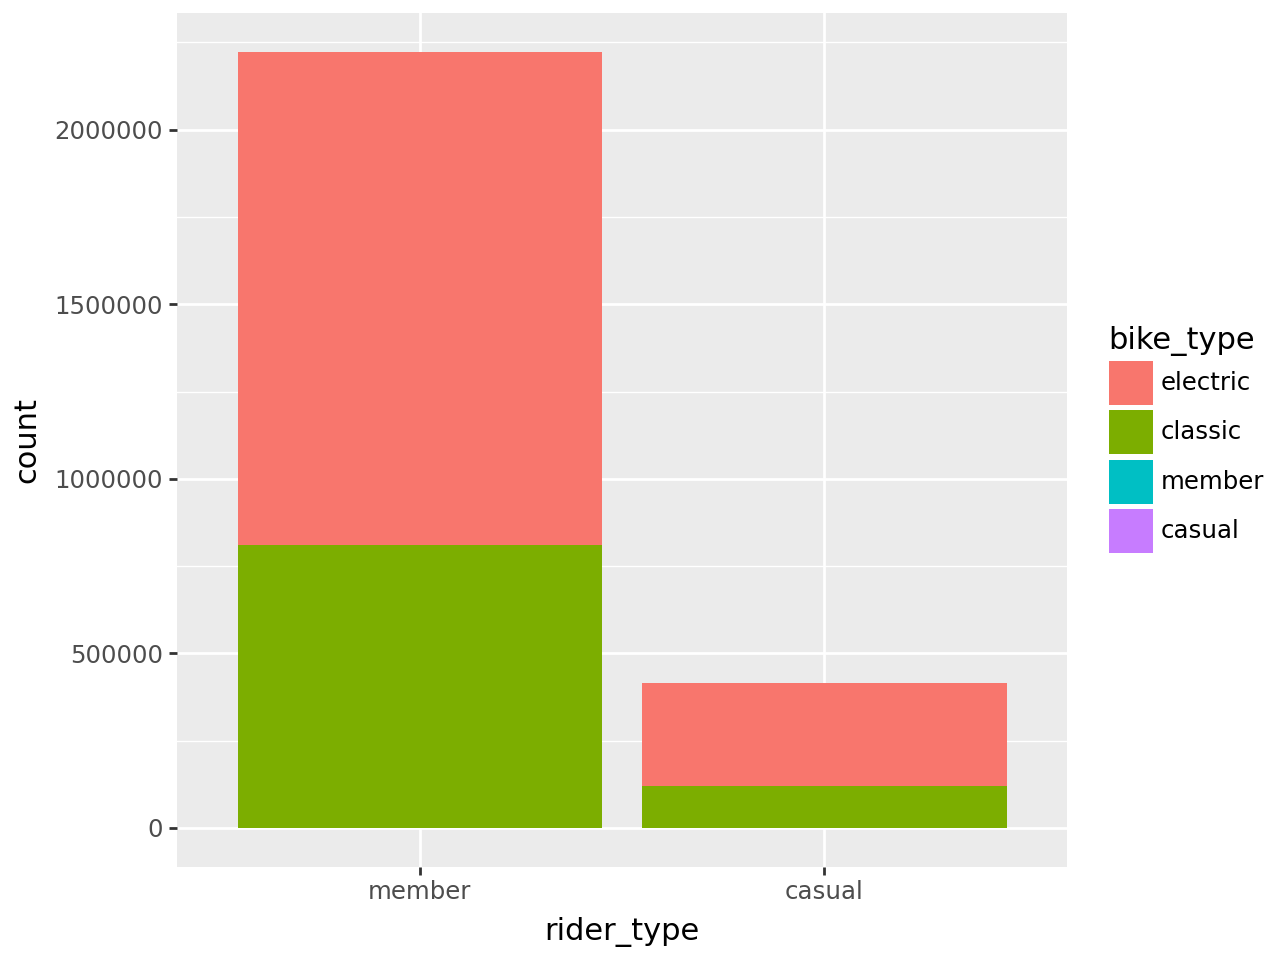

In [41]:
ggplot(trips, aes(x="rider_type", fill="bike_type")) + geom_bar()

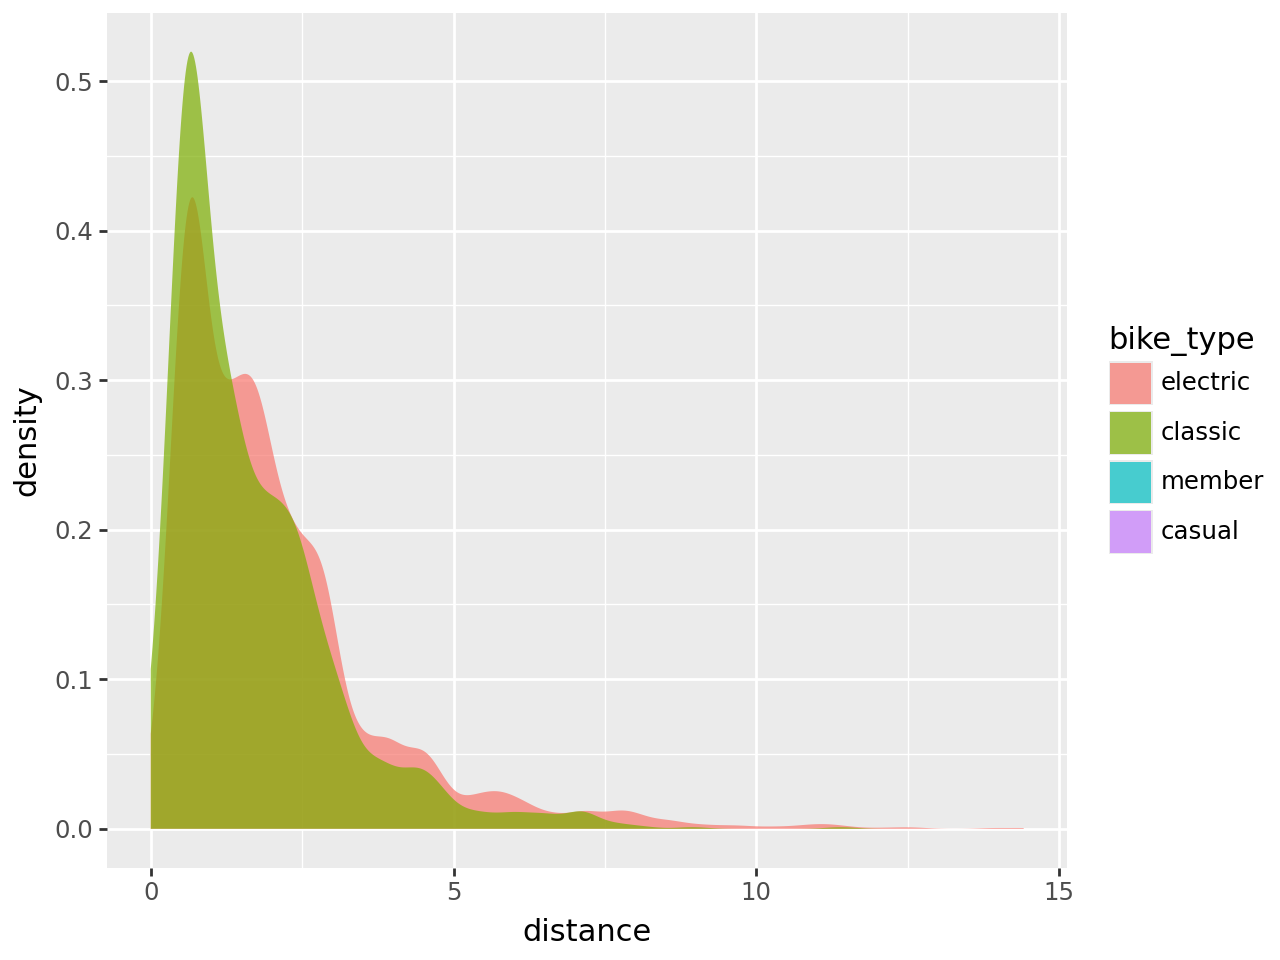

In [42]:
ggplot(trips_speed, aes(x='distance', fill='bike_type')) + geom_density(
    alpha=0.7, color="none"
)

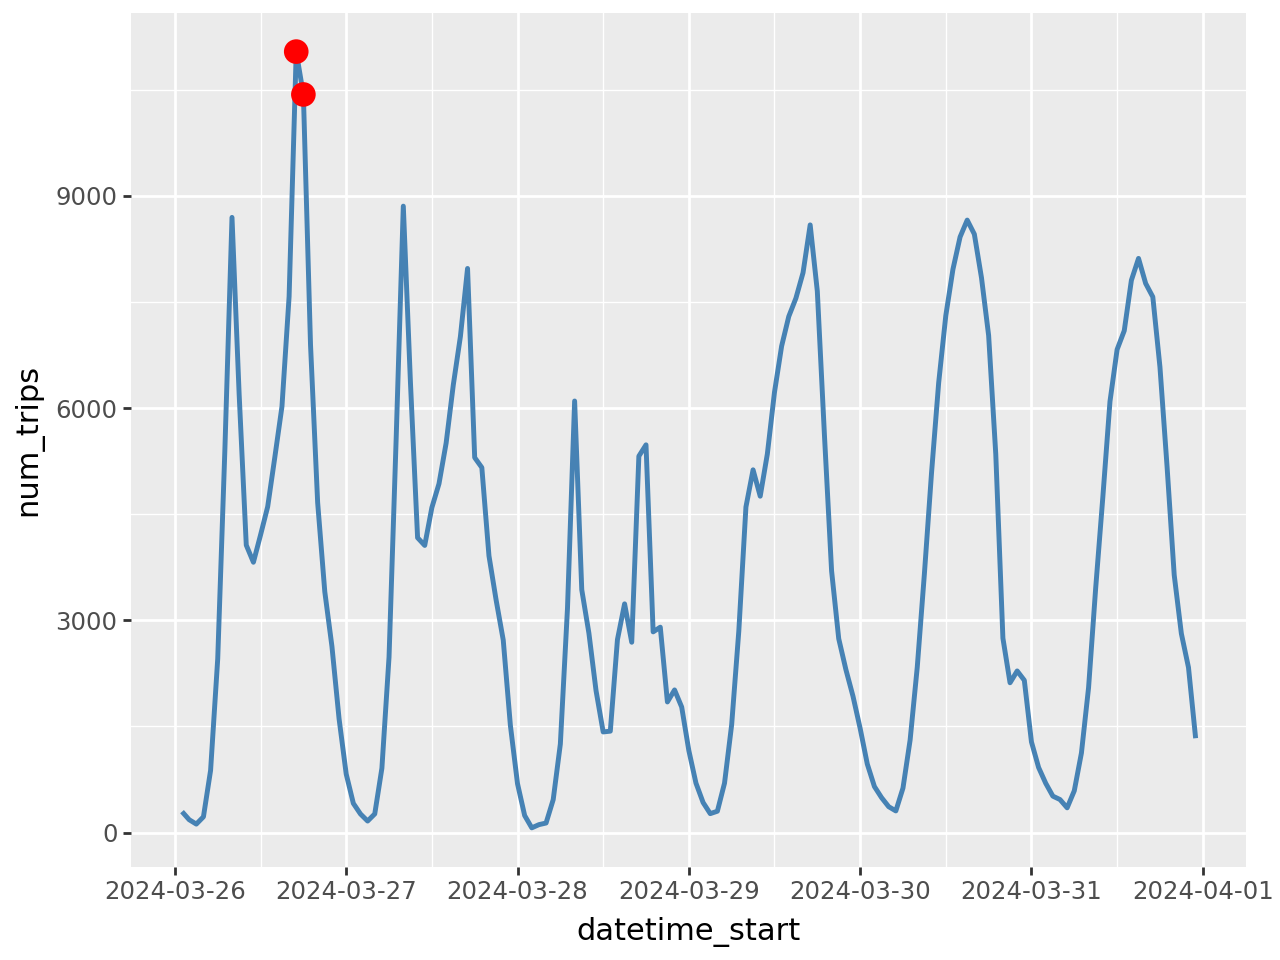

In [44]:
(
    ggplot(trips_hour_num_speed, aes(x='datetime_start', y='num_trips'))
    + geom_line(size=1, color='steelblue')
    + geom_point(
        data=trips_hour_num_speed.filter(pl.col("num_trips") > 9000),
        color='red',
        size=4
    )
)

## Plots for Communication

In [49]:
trips_speed = (
    trips.group_by("neighborhood_start", "neighborhood_end")
    .agg(
        pl.col("duration").dt.total_seconds().median() / 60,
        pl.col("distance").median(),
        pl.col("borough_start").first(),
        pl.col("borough_end").first(),
        pl.len()
    )
    .filter(
        (pl.col("len") > 30)
        & (pl.col("distance") > 0.2)
        & (pl.col("neighborhood_start") != pl.col("neighborhood_end")),
    )
    .with_columns(speed=pl.col("distance") / pl.col("duration"))
    .sort("borough_start")
)
trips_speed

neighborhood_start,neighborhood_end,duration,distance,borough_start,borough_end,len,speed
str,str,f64,f64,str,str,u32,f64
"""Mount Hope""","""Kingsbridge""",10.366667,2.80259,"""Bronx""","""Bronx""",127,0.270346
"""Mott Haven""","""Morningside Heights""",17.5,3.433573,"""Bronx""","""Manhattan""",82,0.196204
"""East Morrisania""","""Morrisania""",4.833333,0.854576,"""Bronx""","""Bronx""",253,0.176809
"""Longwood""","""East Morrisania""",5.066667,1.166172,"""Bronx""","""Bronx""",379,0.230165
"""Longwood""","""Harlem""",14.708333,3.462252,"""Bronx""","""Manhattan""",384,0.235394
…,…,…,…,…,…,…,…
"""Corona""","""Elmhurst""",6.875,1.349366,"""Queens""","""Queens""",394,0.196271
"""Maspeth""","""Middle Village""",6.266667,1.279947,"""Queens""","""Queens""",63,0.204247
"""Maspeth""","""Long Island City""",14.816667,4.022448,"""Queens""","""Queens""",205,0.271481


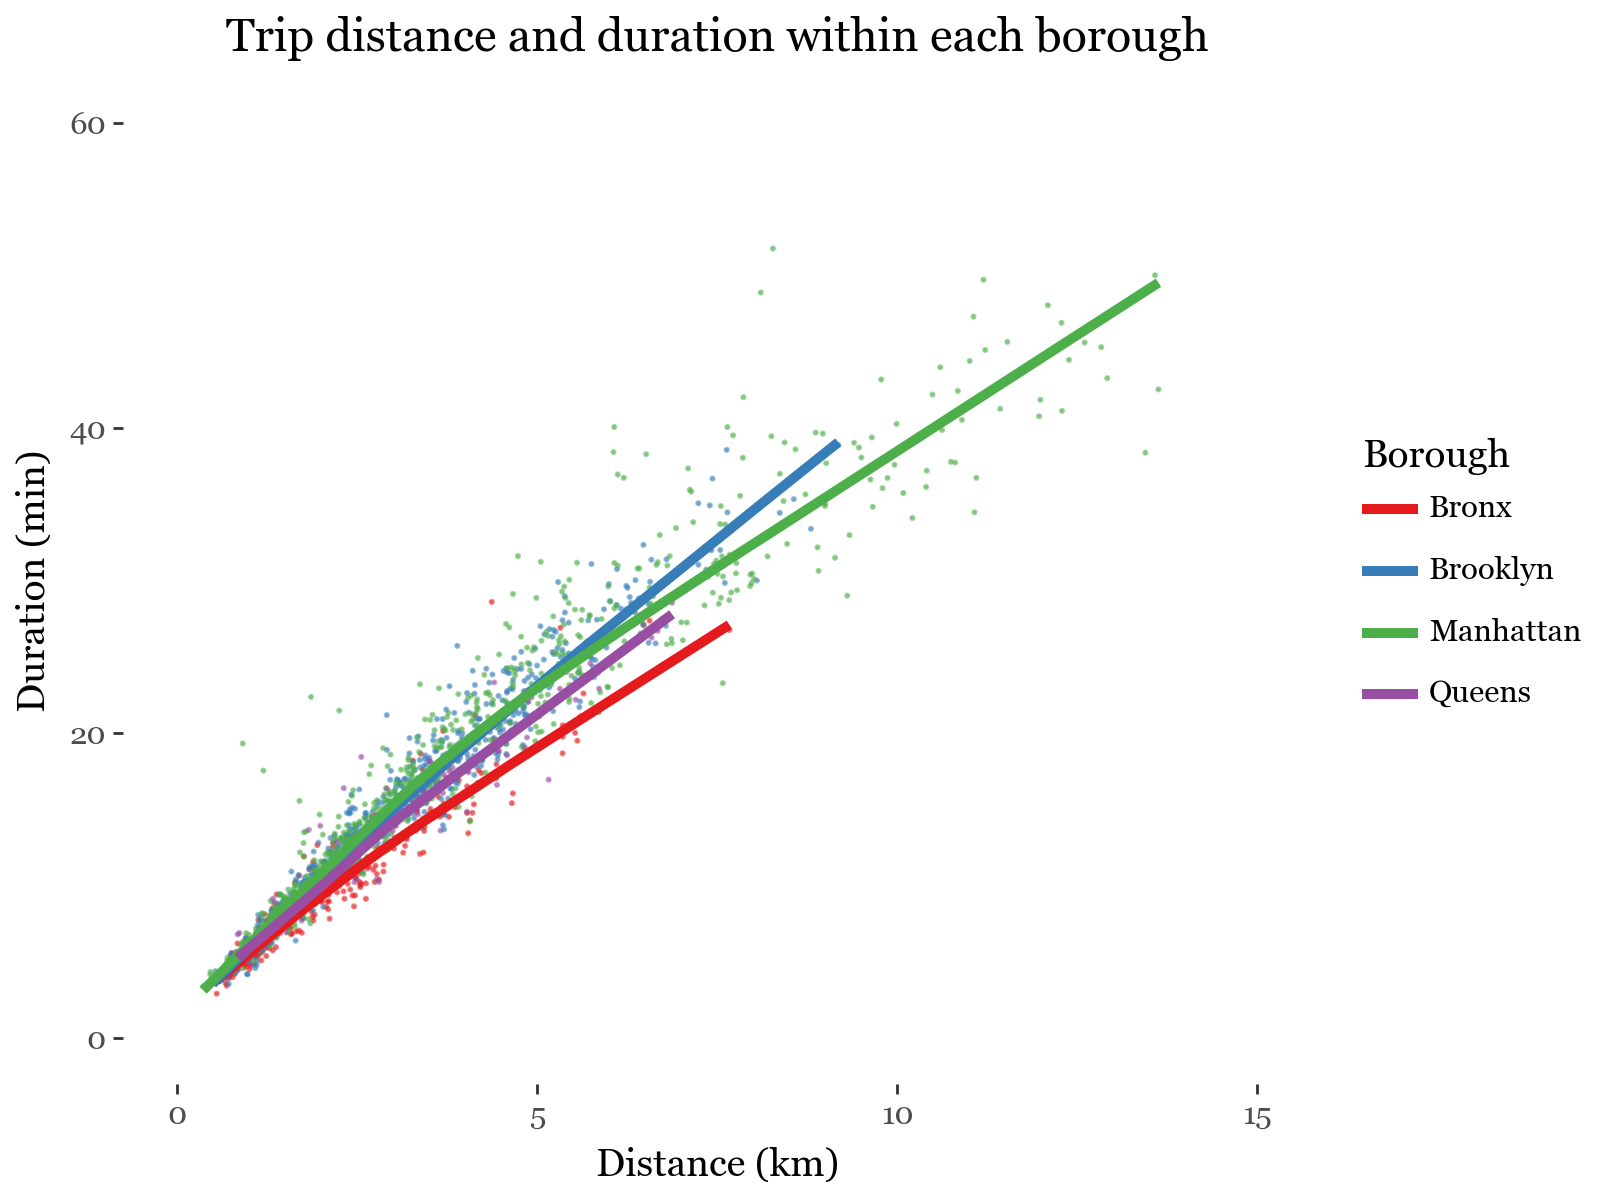

In [57]:
(
    ggplot(
        data=trips_speed.filter(
            pl.col("borough_start") == pl.col("borough_end")
        ),
        mapping=aes(x="distance", y="duration", color="borough_end"),
    )
    + geom_point(size=0.25, alpha=0.5)
    + geom_smooth(method="lowess", size=2, se=False, alpha=0.8)
    + xlim(0, 15)  
    + ylim(0, 60)
    + scale_color_brewer(type="qualitative", palette="Set1")
    + labs(
        title="Trip distance and duration within each borough",
        x="Distance (km)",
        y="Duration (min)",
        color="Borough",
    )
    + theme_tufte(base_family='Georgia', base_size=14)
    + theme(
        figure_size=(8, 6),
        plot_background=element_rect(color="#ffffff"),
    )
)

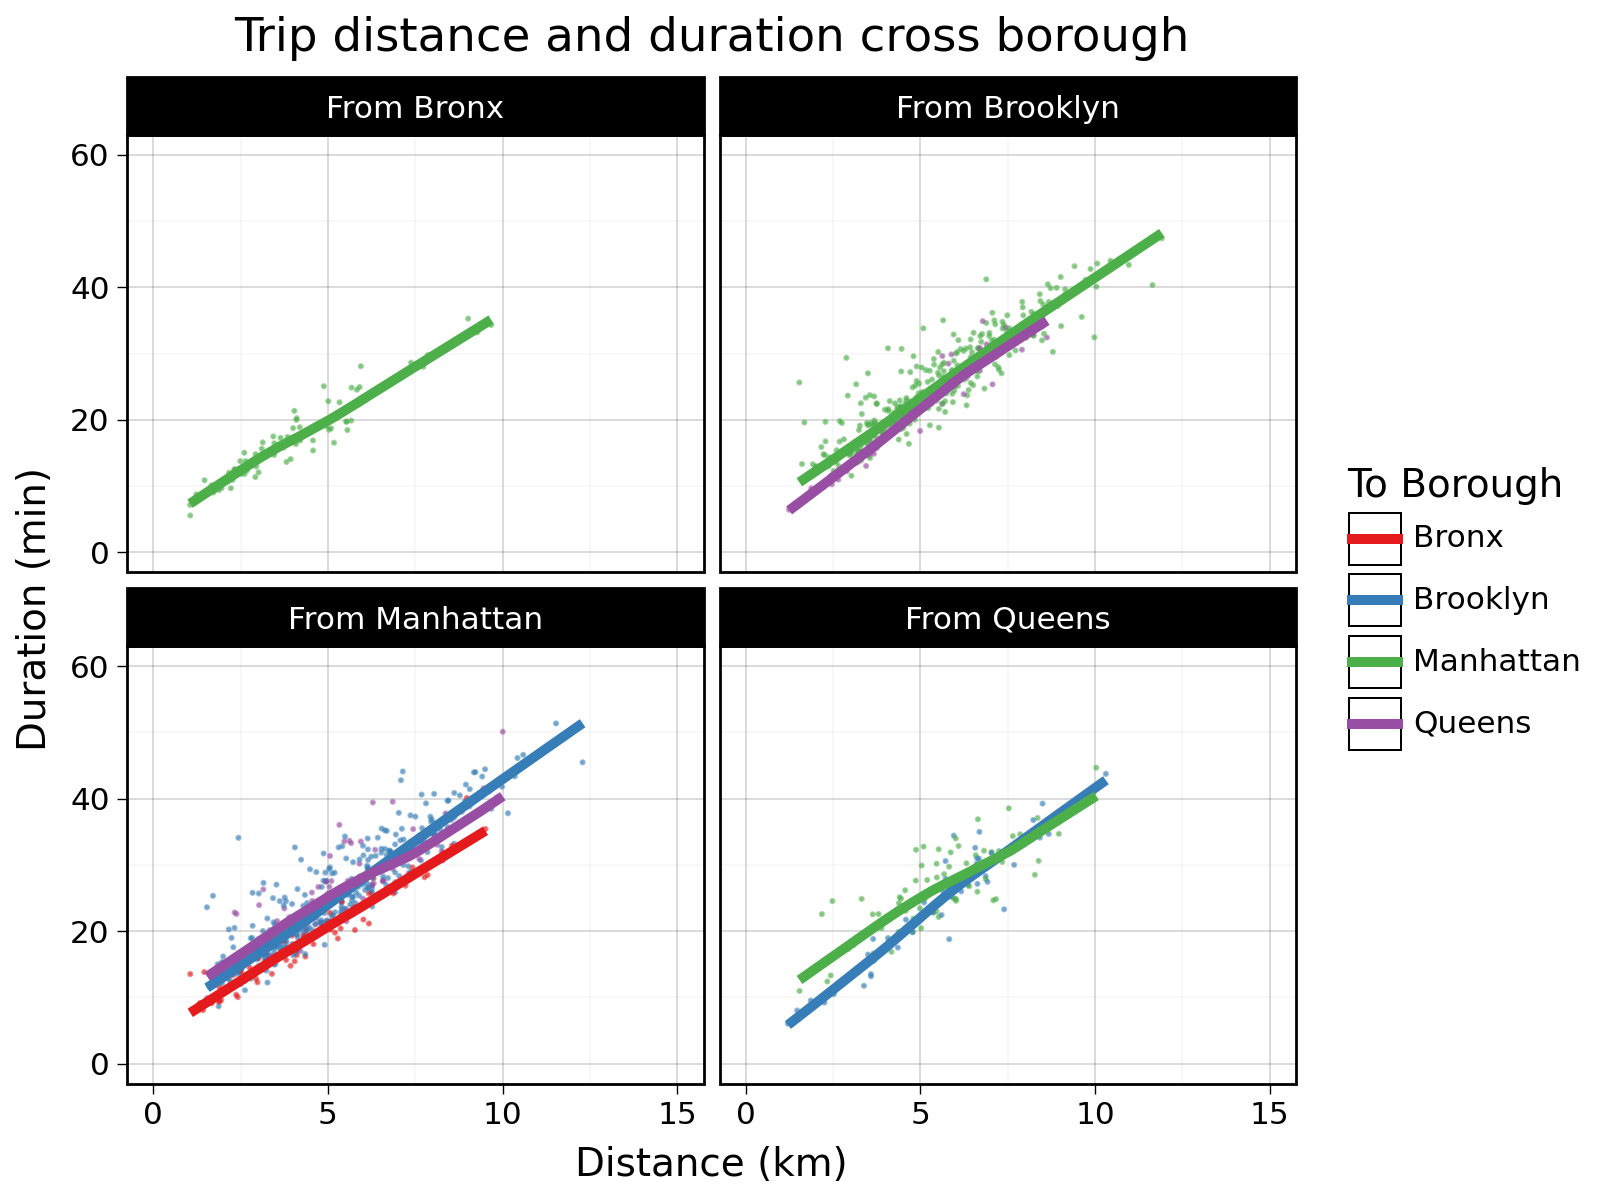

In [60]:
(
    ggplot(
        data=trips_speed.filter(
            pl.col("borough_start") != pl.col("borough_end")
        ).with_columns(
            ("From " + pl.col("borough_start")).alias("borough_start")
        ),
        mapping=aes(x="distance", y="duration", color="borough_end"),
    )
    + geom_point(size=0.25, alpha=0.5)
    + geom_smooth(method="lowess", size=2, se=False, alpha=0.8)
    + xlim(0, 15)
    + ylim(0, 60)
    + scale_color_brewer(type="qualitative", palette="Set1")
    + facet_wrap("borough_start")
    + labs(
        title="Trip distance and duration cross borough",
        x="Distance (km)",
        y="Duration (min)",
        color="To Borough",
    )
    + theme_linedraw(base_size=14)
    + theme(figure_size=(8, 6))
)

## Styling DataFrames With Great Tables

In [78]:
import polars.selectors as cs

busiest_stations = (
    trips.group_by(  
        station=pl.col("station_start"), date=pl.col("datetime_start").dt.date()
    )
    .agg(
        borough=pl.col("borough_start").first(),
        neighborhood=pl.col("neighborhood_start").first(),
        num_rides=pl.len(),
        percent_member=(pl.col("rider_type") == "member").mean(),
        percent_electric=(pl.col("bike_type") == "electric").mean(),
    )
    .sort("date")
    .group_by("station")
    .agg(
        pl.col("borough").first(),
        pl.col("neighborhood").first(),
        pl.col("num_rides").mean(),
        pl.col("percent_member").mean(),
        pl.col("percent_electric").mean(),
        pl.col("num_rides").alias("rides_per_day"),
    )
    .sort("num_rides", descending=True)
    .group_by("borough", maintain_order=True)
    .map_groups(lambda df: df.head(3))
)
busiest_stations


station,borough,neighborhood,num_rides,percent_member,percent_electric,rides_per_day
str,str,str,f64,f64,f64,list[u32]
"""W 21 St & 6 Ave""","""Manhattan""","""Chelsea""",354.16129,0.913765,0.583606,"[325, 88, … 306]"
"""Broadway & W 58 St""","""Manhattan""","""Midtown""",307.548387,0.796369,0.705783,"[222, 65, … 365]"
"""8 Ave & W 31 St""","""Manhattan""","""Chelsea""",288.258065,0.865356,0.640417,"[279, 86, … 286]"
"""Metropolitan Ave & Bedford Ave""","""Brooklyn""","""Williamsburg""",184.870968,0.854857,0.679675,"[173, 59, … 241]"
"""N 7 St & Driggs Ave""","""Brooklyn""","""Williamsburg""",145.709677,0.860029,0.655534,"[134, 51, … 147]"
…,…,…,…,…,…,…
"""Vernon Blvd & 50 Ave""","""Queens""","""Long Island City""",95.16129,0.890379,0.663037,"[94, 28, … 122]"
"""31 St & Newtown Ave""","""Queens""","""Astoria""",78.16129,0.883093,0.596819,"[77, 29, … 61]"
"""Melrose Ave & E 150 St""","""Bronx""","""Melrose""",41.612903,0.834158,0.894699,"[43, 15, … 38]"


In [80]:
from great_tables import GT

GT(busiest_stations)

station,borough,neighborhood,num_rides,percent_member,percent_electric,rides_per_day
W 21 St & 6 Ave,Manhattan,Chelsea,354.16129032258067,0.913764948841179,0.5836060628339382,"[325, 88, 409, 433, 221, 219, 365, 369, 162, 307, 378, 502, 507, 498, 447, 415, 361, 385, 385, 361, 369, 366, 91, 370, 446, 480, 407, 210, 428, 369, 306]"
Broadway & W 58 St,Manhattan,Midtown,307.5483870967742,0.7963690113856159,0.7057834322293212,"[222, 65, 446, 299, 122, 154, 340, 332, 122, 171, 278, 373, 359, 433, 660, 766, 662, 267, 281, 284, 243, 237, 41, 210, 279, 304, 280, 172, 407, 360, 365]"
8 Ave & W 31 St,Manhattan,Chelsea,288.258064516129,0.8653562450153743,0.6404165834717456,"[279, 86, 245, 360, 166, 245, 322, 317, 92, 153, 317, 449, 421, 497, 406, 274, 277, 271, 395, 318, 350, 282, 62, 176, 347, 404, 336, 217, 344, 242, 286]"
Metropolitan Ave & Bedford Ave,Brooklyn,Williamsburg,184.8709677419355,0.8548570633632913,0.6796751094803254,"[173, 59, 231, 208, 114, 97, 216, 240, 88, 134, 172, 244, 247, 200, 219, 225, 269, 169, 158, 173, 176, 181, 88, 218, 211, 230, 180, 90, 224, 256, 241]"
N 7 St & Driggs Ave,Brooklyn,Williamsburg,145.70967741935485,0.8600288134761424,0.655533737720296,"[134, 51, 183, 117, 98, 86, 149, 176, 71, 99, 142, 168, 191, 202, 183, 235, 171, 145, 172, 183, 152, 162, 35, 98, 151, 189, 172, 107, 169, 179, 147]"
Hanson Pl & Ashland Pl,Brooklyn,Fort Greene,143.83870967741936,0.8361605984376713,0.6139227831846854,"[145, 46, 133, 158, 105, 111, 148, 178, 50, 86, 163, 155, 191, 224, 230, 171, 161, 155, 177, 152, 148, 156, 29, 103, 150, 186, 165, 108, 168, 149, 158]"
Queens Plaza North & Crescent St,Queens,Long Island City,126.74193548387096,0.8537365542705813,0.5707317493983467,"[89, 34, 188, 160, 55, 61, 118, 138, 80, 115, 135, 195, 181, 203, 196, 220, 167, 133, 113, 100, 104, 103, 28, 91, 137, 163, 109, 71, 150, 159, 133]"
Vernon Blvd & 50 Ave,Queens,Long Island City,95.16129032258064,0.8903794246434368,0.6630370994599845,"[94, 28, 96, 102, 56, 58, 100, 95, 26, 34, 85, 120, 124, 124, 102, 46, 56, 109, 112, 88, 115, 132, 39, 103, 155, 152, 121, 113, 121, 122, 122]"
31 St & Newtown Ave,Queens,Astoria,78.16129032258064,0.8830932418797895,0.5968191831951197,"[77, 29, 80, 96, 43, 57, 84, 88, 36, 54, 98, 110, 103, 109, 107, 62, 65, 112, 93, 92, 79, 86, 34, 70, 90, 93, 95, 53, 83, 84, 61]"
Melrose Ave & E 150 St,Bronx,Melrose,41.61290322580645,0.8341575787497405,0.8946989054437855,"[43, 15, 36, 54, 39, 24, 63, 58, 24, 32, 38, 45, 68, 59, 73, 37, 39, 47, 43, 41, 45, 41, 10, 29, 43, 49, 47, 34, 48, 28, 38]"


In [79]:
from great_tables import style, md

(
    GT(busiest_stations)
    .tab_stub(rowname_col="station", groupname_col="borough")  
    .cols_label(  
        neighborhood="Neighborhood",
        num_rides="Mean Daily Rides",
        percent_member="Members",
        percent_electric="E-Bikes",
        rides_per_day="Rides Per Day",
    )
    .tab_header(
        title="Busiest Bike Stations in NYC",
        subtitle="In March 2024, Per Borough",
    )
    .tab_stubhead(label="Station")
    .fmt_number(columns="num_rides", decimals=1)
    .fmt_percent(columns=cs.starts_with("percent_"), decimals=0)  
    .fmt_nanoplot(columns="rides_per_day", reference_line="mean")
    .data_color(columns="num_rides", palette="Blues")
    .tab_options(row_group_font_weight="bold")
    .tab_source_note(
        source_note=md(
            "Source: [NYC Citi Bike](https://citibikenyc.com/system-data)"
        )
    )
)

GT(_tbl_data=shape: (12, 7)
┌──────────────┬───────────┬──────────────┬────────────┬──────────────┬──────────────┬─────────────┐
│ station      ┆ borough   ┆ neighborhood ┆ num_rides  ┆ percent_memb ┆ percent_elec ┆ rides_per_d │
│ ---          ┆ ---       ┆ ---          ┆ ---        ┆ er           ┆ tric         ┆ ay          │
│ str          ┆ str       ┆ str          ┆ f64        ┆ ---          ┆ ---          ┆ ---         │
│              ┆           ┆              ┆            ┆ f64          ┆ f64          ┆ list[u32]   │
╞══════════════╪═══════════╪══════════════╪════════════╪══════════════╪══════════════╪═════════════╡
│ W 21 St & 6  ┆ Manhattan ┆ Chelsea      ┆ 354.16129  ┆ 0.913765     ┆ 0.583606     ┆ [325, 88, … │
│ Ave          ┆           ┆              ┆            ┆              ┆              ┆ 306]        │
│ Broadway & W ┆ Manhattan ┆ Midtown      ┆ 307.548387 ┆ 0.796369     ┆ 0.705783     ┆ [222, 65, … │
│ 58 St        ┆           ┆              ┆            ┆              ┆              ┆ 365]        │
│ 8 Ave & W 31 ┆ Manhattan ┆ Chelsea      ┆ 288.258065 ┆ 0.865356     ┆ 0.640417     ┆ [279, 86, … │
│ St           ┆           ┆              ┆            ┆              ┆              ┆ 286]        │
│ Metropolitan ┆ Brooklyn  ┆ Williamsburg ┆ 184.870968 ┆ 0.854857     ┆ 0.679675     ┆ [173, 59, … │
│ Ave &        ┆           ┆              ┆            ┆              ┆              ┆ 241]        │
│ Bedford Ave  ┆           ┆              ┆            ┆              ┆              ┆             │
│ N 7 St &     ┆ Brooklyn  ┆ Williamsburg ┆ 145.709677 ┆ 0.860029     ┆ 0.655534     ┆ [134, 51, … │
│ Driggs Ave   ┆           ┆              ┆            ┆              ┆              ┆ 147]        │
│ …            ┆ …         ┆ …            ┆ …          ┆ …            ┆ …            ┆ …           │
│ Vernon Blvd  ┆ Queens    ┆ Long Island  ┆ 95.16129   ┆ 0.890379     ┆ 0.663037     ┆ [94, 28, …  │
│ & 50 Ave     ┆           ┆ City         ┆            ┆              ┆              ┆ 122]        │
│ 31 St &      ┆ Queens    ┆ Astoria      ┆ 78.16129   ┆ 0.883093     ┆ 0.596819     ┆ [77, 29, …  │
│ Newtown Ave  ┆           ┆              ┆            ┆              ┆              ┆ 61]         │
│ Melrose Ave  ┆ Bronx     ┆ Melrose      ┆ 41.612903  ┆ 0.834158     ┆ 0.894699     ┆ [43, 15, …  │
│ & E 150 St   ┆           ┆              ┆            ┆              ┆              ┆ 38]         │
│ E 161 St &   ┆ Bronx     ┆ Concourse    ┆ 35.483871  ┆ 0.744404     ┆ 0.879168     ┆ [32, 12, …  │
│ River Ave    ┆           ┆              ┆            ┆              ┆              ┆ 50]         │
│ Plaza Dr & W ┆ Bronx     ┆ Mount Eden   ┆ 31.709677  ┆ 0.837427     ┆ 0.948925     ┆ [30, 19, …  │
│ 170 St       ┆           ┆              ┆            ┆              ┆              ┆ 33]         │
└──────────────┴───────────┴──────────────┴────────────┴──────────────┴──────────────┴─────────────┘, _body=<great_tables._gt_data.Body object at 0x000002213CE9C110>, _boxhead=Boxhead([ColInfo(var='station', type=<ColInfoTypeEnum.stub: 2>, column_label='station', column_align='left', column_width=None), ColInfo(var='borough', type=<ColInfoTypeEnum.row_group: 3>, column_label='borough', column_align='left', column_width=None), ColInfo(var='neighborhood', type=<ColInfoTypeEnum.default: 1>, column_label='Neighborhood', column_align='left', column_width=None), ColInfo(var='num_rides', type=<ColInfoTypeEnum.default: 1>, column_label='Mean Daily Rides', column_align='right', column_width=None), ColInfo(var='percent_member', type=<ColInfoTypeEnum.default: 1>, column_label='Members', column_align='right', column_width=None), ColInfo(var='percent_electric', type=<ColInfoTypeEnum.default: 1>, column_label='E-Bikes', column_align='right', column_width=None), ColInfo(var='rides_per_day', type=<ColInfoTypeEnum.default: 1>, column_label='Rides Per Day', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at